In [1]:
import polars as pl
import sourmash
import matplotlib.pyplot as plt
import random
import numpy as np
import scipy

In [2]:
ls ../outputs.cds/cds/*.sig.zip

'../outputs.cds/cds/s__Bariatricus sp004560705.cds.sig.zip'
'../outputs.cds/cds/s__Bifidobacterium thermacidophilum.cds.sig.zip'
'../outputs.cds/cds/s__Blautia_A sp945872375.cds.sig.zip'
'../outputs.cds/cds/s__CAG-269 sp014846485.cds.sig.zip'
'../outputs.cds/cds/s__CAG-465 sp000433755.cds.sig.zip'
'../outputs.cds/cds/s__CAG-873 sp016302215.cds.sig.zip'
'../outputs.cds/cds/s__Cryptobacteroides sp900546925.cds.sig.zip'
'../outputs.cds/cds/s__Fimisoma sp002320005.cds.sig.zip'
'../outputs.cds/cds/s__Gemmiger qucibialis.cds.sig.zip'
'../outputs.cds/cds/s__Holdemanella porci.cds.sig.zip'
'../outputs.cds/cds/s__JAFBIX01 sp021531895.cds.sig.zip'
'../outputs.cds/cds/s__JALFVM01 sp022787145.cds.sig.zip'
'../outputs.cds/cds/s__Lactobacillus amylovorus.cds.sig.zip'
'../outputs.cds/cds/s__Mogibacterium_A kristiansenii.cds.sig.zip'
'../outputs.cds/cds/s__Phascolarctobacterium_A succinatutens.cds.sig.zip'
'../outputs.cds/cds/s__Phascolarctobacterium_A succinatutens_B.cds.sig.zip'
'../outputs.cds/cds/

In [3]:
cds_sketchfile = '../outputs.cds/cds/s__Sodaliphilus sp004557565.cds.sig.zip'
cds3_sketchfile = '../outputs.cds/cds3/s__Sodaliphilus sp004557565.cds3.sig.zip'

In [4]:
sig = sourmash.load_file_as_signatures(cds_sketchfile, ksize=21)
sig = list(sig)
assert len(sig) == 1
sig = sig[0]
full_mh = sig.minhash
assert full_mh.ksize == 21
assert full_mh.scaled == 1000
print(f'cds minhash size: {len(full_mh)}')

cds minhash size: 23799


In [5]:
sig3 = sourmash.load_file_as_signatures(cds3_sketchfile, ksize=21)
sig3 = list(sig3)
assert len(sig3) == 1
sig3 = sig3[0]
cds3_mh = sig3.minhash
assert cds3_mh.ksize == 21
assert cds3_mh.scaled == 1000
print(f'cds3 minhash size: {len(cds3_mh)}')

cds3 minhash size: 10794


In [6]:
hashes = list(cds3_mh.hashes)

In [49]:
xx = []
found_mh = sourmash.MinHash(n=0, ksize=full_mh.ksize, scaled=full_mh.scaled,
                            track_abundance=True)
for i in range(100):
    if i % 10 == 0:
        print('...', i)
    samp = random.choices(hashes, k=500)
    found_mh.add_many(samp)

    cds_breadth = full_mh.contained_by(found_mh)
    cds3_breadth = cds3_mh.contained_by(found_mh)

    depth = sum(found_mh.hashes.values())
    xx.append(dict(i=i,
                   cds_breadth=cds_breadth,
                   cds3_breadth=cds3_breadth,
                   intersect_bp=len(found_mh)*1000,
                   weighted_bp=depth*1000))

samp_df = pl.DataFrame(xx)

... 0
... 10
... 20
... 30
... 40
... 50
... 60
... 70
... 80
... 90


In [50]:
len(samp_df)

100

In [51]:
samp_df

i,cds_breadth,cds3_breadth,intersect_bp,weighted_bp
i64,f64,f64,i64,i64
0,0.020547,0.045303,489000,500000
1,0.040506,0.089309,964000,1000000
2,0.058868,0.129794,1401000,1500000
3,0.07702,0.169817,1833000,2000000
4,0.094206,0.207708,2242000,2500000
…,…,…,…,…
95,0.448212,0.988234,10667000,48000000
96,0.448548,0.988975,10675000,48500000
97,0.4488,0.989531,10681000,49000000


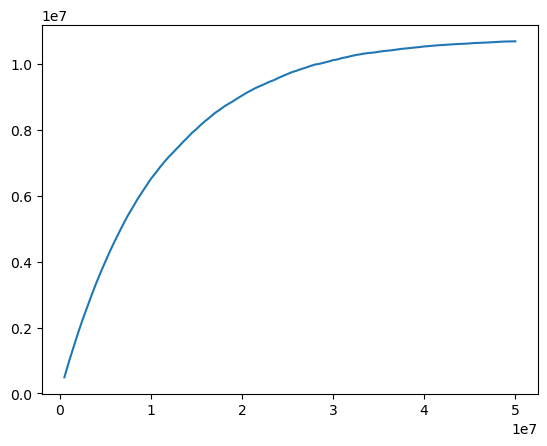

In [52]:
plt.plot(samp_df['weighted_bp'], samp_df['intersect_bp'])

In [53]:
def coverage_curve(x, G, C):
    return G*(1 - np.exp(-C*x))

In [54]:
def do_fit(contain_df, *, fn=coverage_curve, p0=None):
    "Fit to given function, which takes two parameters, G and C. Return fit values & params."
    if p0 is None:
        p0 = (max(contain_df['weighted_bp']), .00001)
    popt, pcov = scipy.optimize.curve_fit(fn, contain_df['weighted_bp'], contain_df['intersect_bp'], p0)
    G, C = popt

    y = np.asarray(contain_df['weighted_bp'])
    yfit = coverage_curve(y, G, C)

    # residual sum of squares
    ss_res = np.sum((y - yfit) ** 2)
    # total sum of squares
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    # r-squared
    r2 = 1 - (ss_res / ss_tot)

    return yfit, (G, C), r2

In [57]:
yfit, params, r2 = do_fit(samp_df)
print(params)

(np.float64(10794955.343318379), np.float64(9.166834259681721e-08))


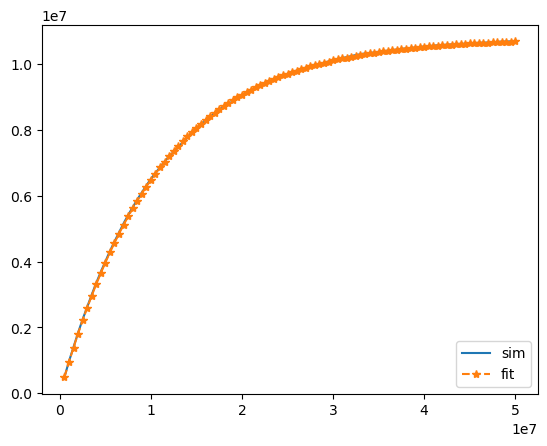

In [56]:
plt.plot(samp_df['weighted_bp'], samp_df['intersect_bp'], label='sim')
plt.plot(samp_df['weighted_bp'], yfit, '*--', label='fit')
plt.legend(loc='lower right')

In [59]:
GSIZE=params[0]
p0 = (max(samp_df['weighted_bp']), 0.9)

def adj_coverage_curve(x, c, e):
    return c*(1 - np.exp(-e*x/GSIZE))

yfit, params, r2 = do_fit(samp_df, fn=adj_coverage_curve, p0=p0)
print(params)

(np.float64(10794955.342687761), np.float64(0.9895556649778144))


In [60]:
GSIZE

np.float64(10794955.343318379)

In [61]:
len(cds3_mh) * 1000


10794000